In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

In [2]:
# Load dataset
df = pd.read_excel(r"C:\Users\User\OneDrive\Documents\Brazilian-Ecommerce-Cleaned.xlsx", parse_dates=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
print("Done!")

Done!



Observed Values:

year_month
2016-10-01     334.0
2016-12-01       1.0
2017-01-01     948.0
2017-02-01    1893.0
2017-03-01    3014.0
2017-04-01    2631.0
2017-05-01    4162.0
2017-06-01    3628.0
2017-07-01    4655.0
2017-08-01    4974.0
2017-09-01    4923.0
2017-10-01    5386.0
2017-11-01    8683.0
2017-12-01    6299.0
2018-01-01    8161.0
2018-02-01    7645.0
2018-03-01    8201.0
2018-04-01    8035.0
2018-05-01    8052.0
2018-06-01    7294.0
2018-07-01    7148.0
2018-08-01    7323.0
Name: order_count, dtype: float64

Trend Values:

year_month
2016-10-01            NaN
2016-12-01            NaN
2017-01-01            NaN
2017-02-01    1789.166667
2017-03-01    2410.416667
2017-04-01    3021.583333
2017-05-01    3587.250000
2017-06-01    4003.083333
2017-07-01    4391.750000
2017-08-01    4998.083333
2017-09-01    5597.416667
2017-10-01    6112.166667
2017-11-01    6626.916667
2017-12-01    7122.666667
2018-01-01    7616.583333
2018-02-01    7784.750000
2018-03-01    7815.083333
2018-

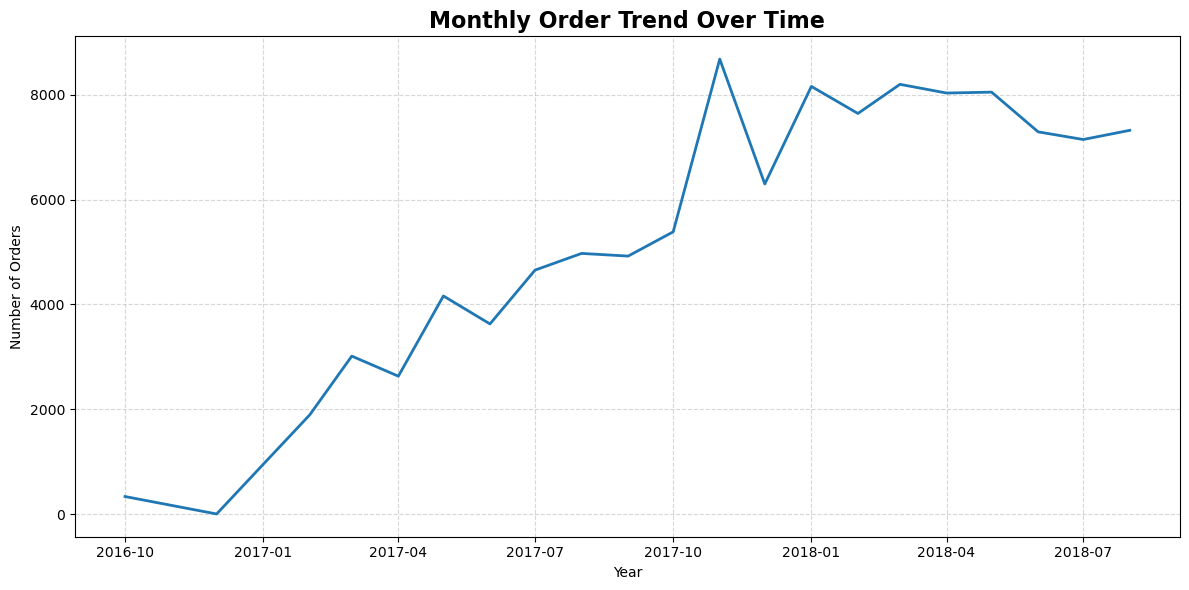

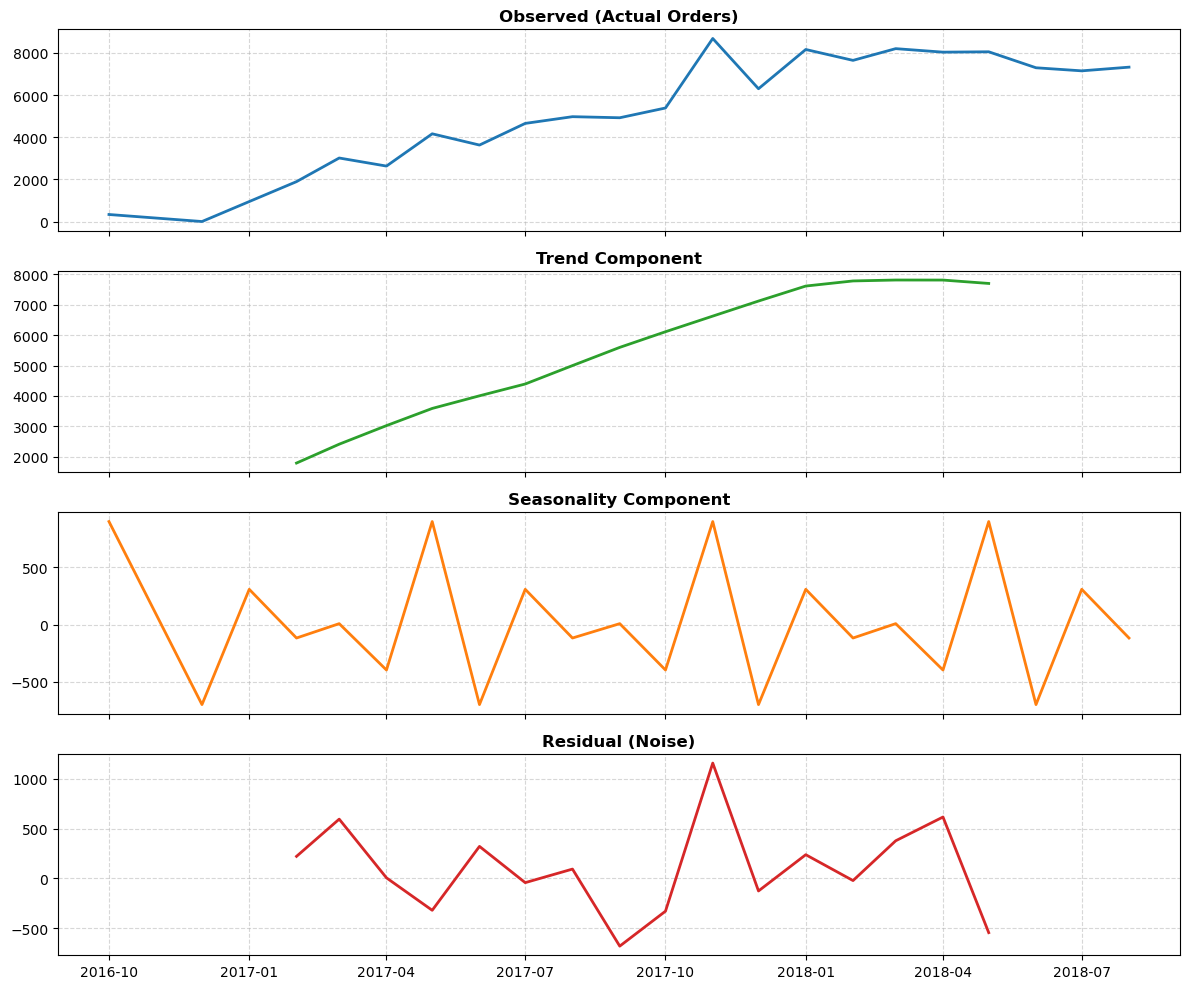

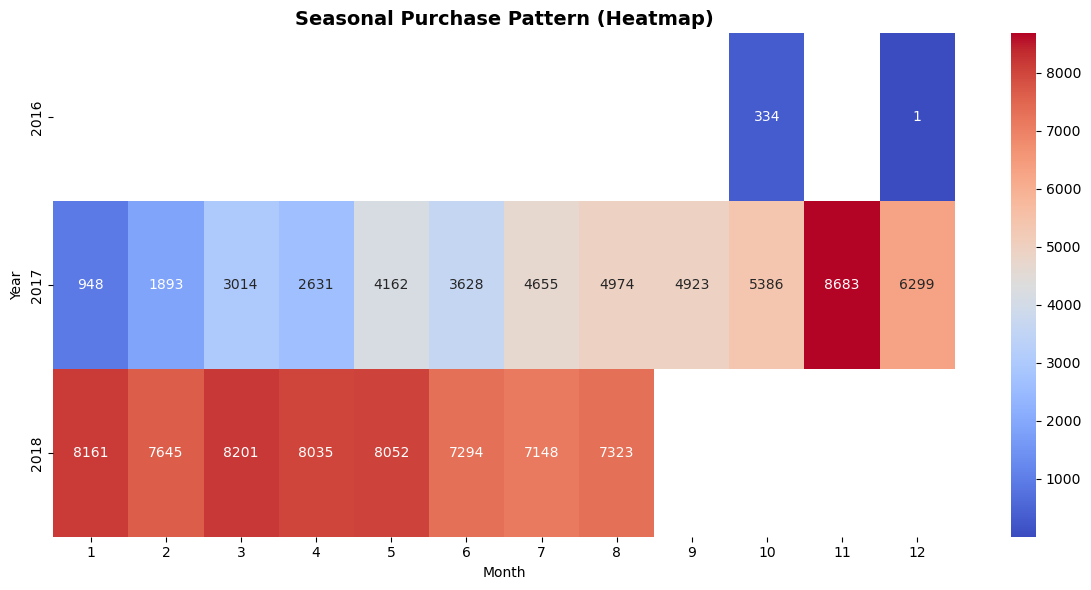


All graphs saved successfully!


In [4]:
output_dir = Path(r"D:\Olist_Analysis_Project\Outputs\Module4") 
output_dir.mkdir(parents=True, exist_ok=True)

# ── PREPARE DATA ──────────────────────────────────────────────────────────────

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Create Year-Month column
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")

# Monthly order count
monthly_orders = (
    df.groupby("year_month")
    .size()
    .reset_index(name="order_count")
)

# Convert back to datetime for plotting
monthly_orders["year_month"] = monthly_orders["year_month"].dt.to_timestamp()

# Set index for decomposition
ts = monthly_orders.set_index("year_month")["order_count"]

# ── TIME SERIES DECOMPOSITION ─────────────────────────────────────────────────
# period=6 is used intentionally: seasonal_decompose requires a minimum of
# 2 × period data points to complete full cycles. Since this dataset spans
# only 22 months (2016–2018), period=12 would require 24 months and would
# fail or produce a largely NaN trend component. period=6 ensures at least
# 3 complete cycles across the available data, making the decomposition
# statistically valid within this dataset's constraints.

decomp = seasonal_decompose(ts, model="additive", period=6)

print("\nObserved Values:\n")
print(decomp.observed)

print("\nTrend Values:\n")
print(decomp.trend)

print("\nSeasonal Values:\n")
print(decomp.seasonal)

print("\nResidual Values:\n")
print(decomp.resid)

# Extract recurring seasonal pattern by month number
seasonal_by_month = decomp.seasonal.copy()
seasonal_by_month.index = seasonal_by_month.index.month

peak_month_num   = seasonal_by_month.groupby(seasonal_by_month.index).mean().idxmax()
trough_month_num = seasonal_by_month.groupby(seasonal_by_month.index).mean().idxmin()

month_names = {1:"January", 2:"February", 3:"March", 4:"April",
               5:"May", 6:"June", 7:"July", 8:"August",
               9:"September", 10:"October", 11:"November", 12:"December"}

trend_direction = (
    "upward"
    if decomp.trend.dropna().iloc[-1] > decomp.trend.dropna().iloc[0]
    else "downward"
)

print("\n── Decomposition Insights ──")
print(f"  Overall trend direction      : {trend_direction}")
print(f"  Peak recurring month         : {month_names[peak_month_num]}")
print(f"  Trough recurring month       : {month_names[trough_month_num]}")
print("  Use peak/trough months to guide inventory stocking and campaign timing.")

# ── PLOT 1: ORIGINAL MONTHLY TREND ───────────────────────────────────────────

plt.figure(figsize=(12, 6))
plt.plot(ts, linewidth=2)
plt.title("Monthly Order Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir/"monthly_trend.png", dpi=300)
plt.show()

# ── PLOT 2: DECOMPOSITION (4-PANEL) ──────────────────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

axes[0].plot(decomp.observed, color=colors[0], linewidth=2)
axes[0].set_title("Observed (Actual Orders)", fontweight="bold")

axes[1].plot(decomp.trend, color=colors[1], linewidth=2)
axes[1].set_title("Trend Component", fontweight="bold")

axes[2].plot(decomp.seasonal, color=colors[2], linewidth=2)
axes[2].set_title("Seasonality Component", fontweight="bold")

axes[3].plot(decomp.resid, color=colors[3], linewidth=2)
axes[3].set_title("Residual (Noise)", fontweight="bold")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(output_dir/"time_series_decomposition.png", dpi=300)
plt.show()

# ── PLOT 3: SEASONAL PATTERN HEATMAP ─────────────────────────────────────────

monthly_orders["month"] = monthly_orders["year_month"].dt.month
monthly_orders["year"]  = monthly_orders["year_month"].dt.year

pivot = monthly_orders.pivot(index="year", columns="month", values="order_count")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="coolwarm", annot=True, fmt=".0f")
plt.title("Seasonal Purchase Pattern (Heatmap)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig(output_dir/"seasonality_heatmap.png", dpi=300)
plt.show()

print("\nAll graphs saved successfully!")